In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os

df = pd.read_csv(os.path.join('..', 'data', 'processed', 'features.csv'))
model = joblib.load(os.path.join('..', 'models', 'xgb_best.pkl'))

# recreate X exactly as in modelling notebook
drop_cols = ['EventID', 'GaugeID', 'Start Date', 'End Date',
             'Peak FL Date', 'Flood Type', 'Peak Discharge Date',
             'Station', 'River Name/ Tributory/ SubTributory',
             'Basin', 'Privacy', 'Reliability',
             'KoppenGeiger Climate Type', 'Land cover',
             'Soil type', 'lithology type', 'State']

df_model = df.drop(columns=[c for c in drop_cols if c in df.columns])
obj_cols = df_model.select_dtypes(include=['str', 'datetime64']).columns.tolist()
df_model  = df_model.drop(columns=obj_cols)

X = df_model.drop(columns=['label'])
y = df_model['label']

print(f"X: {X.shape}, model loaded: {type(model).__name__}")

X: (4548, 121), model loaded: XGBClassifier


In [3]:
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (4548, 121)


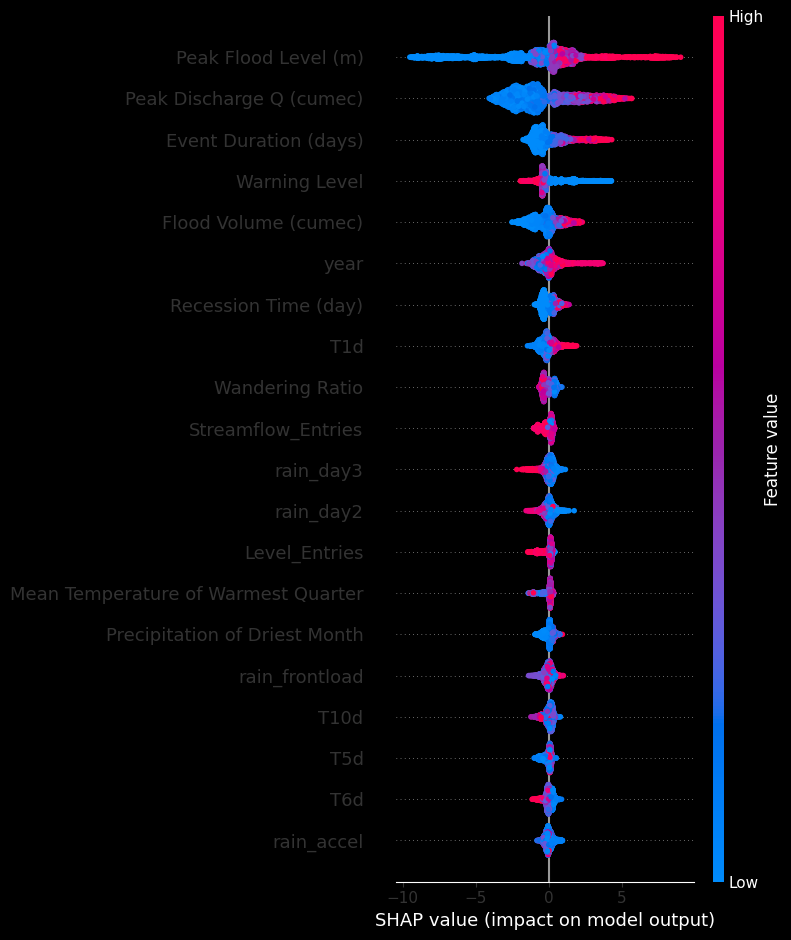

In [4]:
# shows which features drive predictions most across all events
plt.figure()
shap.summary_plot(shap_values, X, max_display=20, show=False)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'shap_summary.png'),
            dpi=150, bbox_inches='tight')
plt.show()

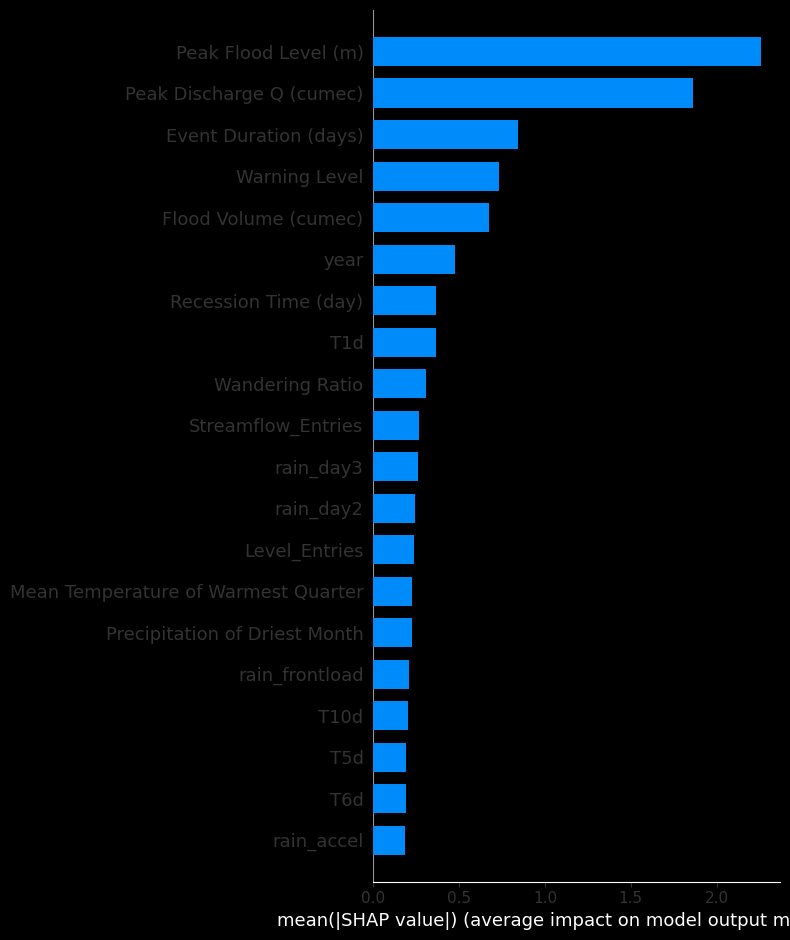

In [5]:
# cleaner version for papers — ranks features by mean impact
plt.figure()
shap.summary_plot(shap_values, X, plot_type='bar', max_display=20, show=False)
plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'figures', 'shap_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import joblib

shap_df = pd.DataFrame(shap_values, columns=X.columns)
shap_df.to_csv(os.path.join('..', 'outputs', 'shap_values.csv'), index=False)
print("SHAP values saved.")

SHAP values saved.
